In [ ]:
# ==================================
#  IMPORT LIBRARIES
# ==================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")


In [ ]:
# ==================================
#  LOAD DATA
# ==================================

In [2]:
df = pd.read_csv("superstore.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())

Rows: 51290
Columns: 27
          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  记录数               Order.Date        Order.ID  ... Sales  \
0       0.0     US    1  2011-01-07 00:00:00.000  CA-2011-130813  ...    19   
1       0.0     US    1  2011-01-21 00:00:00.000  CA-2011-148614  ...    19   
2       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...    21   
3       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...   111   
4       0.0     US    1  2011-09-29 00:00:00.000  CA-2011-146969  ...     6   

    Segment         

In [ ]:
# ==================================
#  CLEAN COLUMN NAMES
# ==================================


In [3]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print(df.columns)

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', '记录数', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id',
       'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'year', 'market2', 'weeknum'],
      dtype='object')


In [ ]:
# ==================================
#  DATA CLEANING
# ==================================


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

df.drop_duplicates(inplace=True)

print(df.isnull().sum())


category          0
city              0
country           0
customer_id       0
customer_name     0
discount          0
market            0
记录数               0
order_date        0
order_id          0
order_priority    0
product_id        0
product_name      0
profit            0
quantity          0
region            0
row_id            0
sales             0
segment           0
ship_date         0
ship_mode         0
shipping_cost     0
state             0
sub_category      0
year              0
market2           0
weeknum           0
dtype: int64


In [ ]:
# ==================================
#  FEATURE ENGINEERING
# ==================================

In [5]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter

df['profit_margin'] = df['profit'] / df['sales']

df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
# ==================================
#  KPI CALCULATIONS
# ==================================

In [6]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
avg_shipping = df['shipping_days'].mean()
profit_margin = total_profit / total_sales

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Avg Shipping Days:", round(avg_shipping,2))
print("Profit Margin:", round(profit_margin*100,2), "%")

Total Sales: 12642905
Total Profit: 1467457.29
Total Orders: 25035
Total Customers: 4873
Avg Shipping Days: 3.97
Profit Margin: 11.61 %


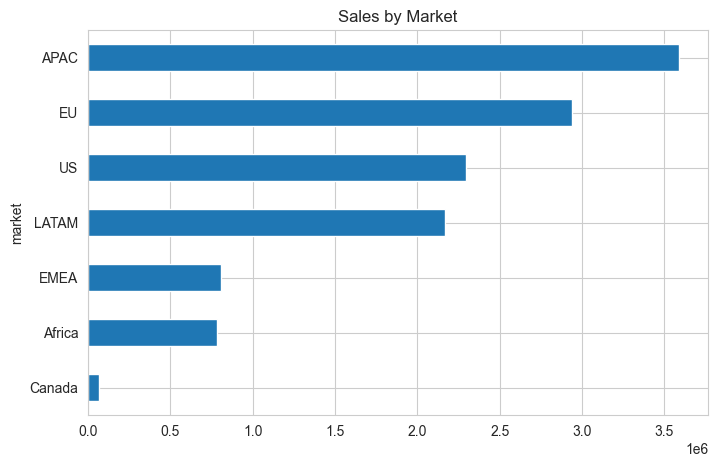

In [7]:
market_sales = df.groupby("market")["sales"].sum().sort_values()

market_sales.plot(kind="barh", figsize=(8,5))
plt.title("Sales by Market")
plt.show()

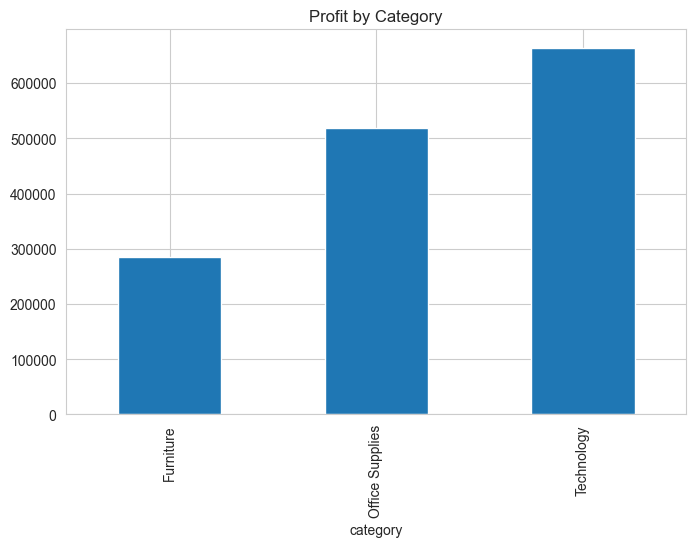

In [8]:
category_profit = df.groupby("category")["profit"].sum()

category_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Category")
plt.show()

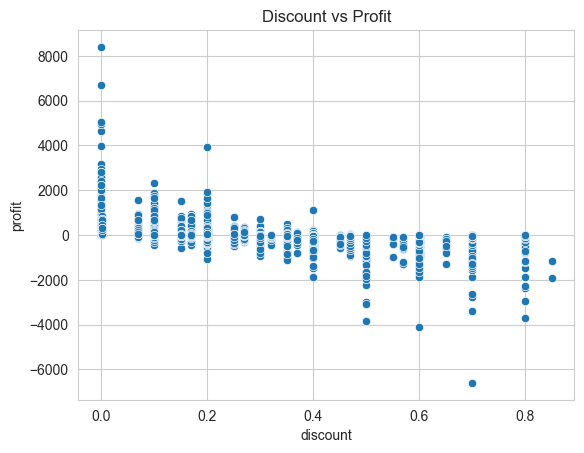

In [9]:
sns.scatterplot(data=df, x="discount", y="profit")
plt.title("Discount vs Profit")
plt.show()

In [10]:
sub_profit = df.groupby("sub_category")["profit"].sum().sort_values()

print("Loss Making Sub-Categories:")
print(sub_profit.head(5))

Loss Making Sub-Categories:
sub_category
Tables      -64083.3887
Fasteners    11525.4241
Labels       15010.5120
Supplies     22583.2631
Envelopes    29601.1163
Name: profit, dtype: float64


In [ ]:
# ==================================
#  RFM SEGMENTATION
# ==================================


In [11]:
snapshot_date = df['order_date'].max()

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [12]:
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R'].astype(str) +
    rfm['F'].astype(str) +
    rfm['M'].astype(str)
)

print(rfm.head())

             Recency  Frequency  Monetary  R  F  M RFM_Score
customer_id                                                 
AA-103151          8         10      1445  4  2  2       422
AA-103152         13         16      6105  4  4  4       444
AA-103153        694          5       633  1  1  1       111
AA-103154        184         11      5565  2  3  4       234
AA-103751          6          9      2407  4  2  3       423


In [13]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return "Champions"
    elif row['F'] == 4:
        return "Loyal Customers"
    elif row['R'] == 1:
        return "At Risk"
    else:
        return "Potential"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Potential          2541
At Risk            1129
Loyal Customers     890
Champions           313
Name: count, dtype: int64


In [16]:
monthly_sales = df.groupby(
    pd.Grouper(key='order_date', freq='ME')
)['sales'].sum().reset_index()

monthly_sales['month_number'] = np.arange(len(monthly_sales))

In [17]:
X = monthly_sales[['month_number']]
y = monthly_sales['sales']

model = LinearRegression()
model.fit(X, y)

future_months = pd.DataFrame({
    'month_number': np.arange(len(monthly_sales), len(monthly_sales)+3)
})

future_predictions = model.predict(future_months)

print("Next 3 Month Forecast:", future_predictions)

Next 3 Month Forecast: [407485.56294326 413366.85717904 419248.15141482]


In [18]:
df.to_csv("clean_superstore.csv", index=False)
rfm.to_csv("rfm_segmentation.csv")